In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [77]:
df=pd.read_csv('hotel_bookings_cleaned.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date_month_num,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,7,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,7,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,7,2015-07-01
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,7,2015-07-01
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,7,2015-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87223,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,0,Transient,96.14,0,0,Check-Out,2017-09-06,8,2017-08-30
87224,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,0,Transient,225.43,0,2,Check-Out,2017-09-07,8,2017-08-31
87225,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,0,Transient,157.71,0,4,Check-Out,2017-09-07,8,2017-08-31
87226,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,0,Transient,104.40,0,0,Check-Out,2017-09-07,8,2017-08-31


In [108]:
_cols = [
    'lead_time', 'adults', 'children', 'babies', 'adr',
    'previous_cancellations', 'previous_bookings_not_canceled', 
    'booking_changes', 'total_of_special_requests', 
    'stays_in_week_nights', 'stays_in_weekend_nights',
    'required_car_parking_spaces', 'days_in_waiting_list',
    'arrival_date_year', 'arrival_date_week_number', 
    'arrival_date_day_of_month', 'is_repeated_guest',
    'arrival_date_month_num', 'agent', 'company'
] + [col for col in df.columns if col.startswith(('deposit_type_', 'market_segment_', 'customer_type_', 'hotel_', 'meal_', 'distribution_channel_', 'reserved_room_type_', 'assigned_room_type_'))]

X = df[_cols]
y = df['is_canceled']


In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [111]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_scaled, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [112]:
y_ = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_))

Accuracy: 0.7505445374297833


<Axes: xlabel='is_canceled'>

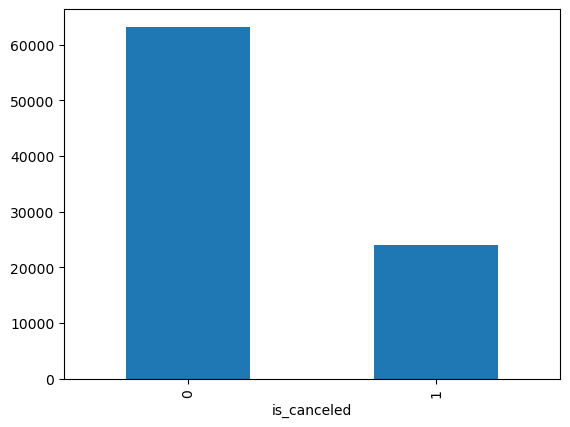

In [113]:
df['is_canceled'].value_counts().plot(kind='bar')